# 15 — Entrenamiento de Modelos ML con Estrategia Robusta de Desbalance

**Proyecto**: Pan-Andean GLOF Susceptibility Assessment  
**Objetivo**: Entrenar modelos ML capaces de identificar lagunas con alta susceptibilidad a GLOF  
**Desafío clave**: Desbalance severo de clases (~1:50 a 1:70 — GLOFs vs. lagunas sin GLOF)  

## Estrategia para el Desbalance de Clases

Usamos **5 técnicas complementarias** para maximizar la robustez y la credibilidad ante revisores:

| Técnica | Propósito |
|---------|----------|
| `scale_pos_weight` / `class_weight='balanced'` | Penalizar errores en clase minoritaria |
| SMOTE + Tomek Links (SMOTETomek) | Sobremuestreo sintético + limpieza de frontera |
| Umbral de decisión óptimo (Youden J) | No usar 0.5 por defecto — optimizar F1/recall |
| PR-AUC como métrica principal | Más informativa que ROC-AUC con clases desbalanceadas |
| Leave-One-Country-Out CV | Validación geográfica — clave para Nature Geoscience |

> **Nota para revisores**: El ratio de desbalance (~1:50) es comparable al de estudios de
> deslizamientos (landslides) y tsunamis publicados en Nature Geoscience y Science Advances.
> La combinación de SMOTETomek + calibración de probabilidades + PR-AUC es el estándar
> actual en la literatura de riesgos naturales con datos raros.


In [1]:
# --- GLOF PROJECT STANDARD SETUP ---
import os
import sys
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
try:
    import geopandas as gpd
except ImportError:
    pass

# ── Rutas ──────────────────────────────────────────────────────────────────
project_root = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
sys.path.insert(0, str(project_root))

# Recarga de módulos de src (opcional para desarrollo)
import importlib
import src.gpu_utils
importlib.reload(src.gpu_utils)

# Fix PROJ: usar proj.db de rasterio (v1.6) en vez del de pyproj (v1.4)
# El pyproj bundled tiene VERSION.MINOR=4 pero rasterio necesita >=6
if 'PROJ_LIB' in os.environ:
    del os.environ['PROJ_LIB']
try:
    import rasterio as _rio
    _proj_data = Path(_rio.__file__).parent / 'proj_data'
    if _proj_data.exists():
        os.environ['PROJ_LIB'] = str(_proj_data)
    del _rio, _proj_data
except Exception:
    pass

import numpy as np
import pandas as pd
try:
    import geopandas as gpd
except ImportError:
    pass

import src.gpu_utils

import src.gpu_utils

import src.gpu_utils

import src.gpu_utils

import time
import json
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import joblib

# Sklearn — métricas y validación
from sklearn.model_selection import (
    StratifiedKFold, cross_val_score, cross_validate,
    LeaveOneGroupOut, train_test_split
)
from sklearn.metrics import (
    roc_auc_score, average_precision_score, f1_score,
    precision_recall_curve, roc_curve, confusion_matrix,
    ConfusionMatrixDisplay, classification_report,
    matthews_corrcoef, balanced_accuracy_score
)
from sklearn.preprocessing import StandardScaler, label_binarize
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from sklearn.pipeline import Pipeline

# Sklearn — modelos
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.linear_model import LogisticRegression

# Imbalanced-learn — manejo de desbalance
from imblearn.combine import SMOTETomek
from imblearn.over_sampling import SMOTE, BorderlineSMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.metrics import geometric_mean_score

# Boosting
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

DATA_DIR   = project_root / 'data' / 'processed'
MODELS_DIR = project_root / 'models'
FIG_DIR    = project_root / 'figures' / 'ml'
MODELS_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)

RANDOM_STATE = 42
N_SPLITS     = 5   # StratifiedKFold

print(f'Inicio: {datetime.now():%Y-%m-%d %H:%M:%S}')
print(f'Datos : {DATA_DIR}')
print(f'Modelos: {MODELS_DIR}')


Inicio: 2026-05-06 13:42:32
Datos : D:\Research-Dev\AUP_Articulos_Inves\GLOF_Andes_Project-Paper\data\processed
Modelos: D:\Research-Dev\AUP_Articulos_Inves\GLOF_Andes_Project-Paper\models


In [2]:
# ── Detección GPU ──────────────────────────────────────────────────────────
import os
os.environ['CUDA_PATH'] = '/opt/cuda'

USE_GPU  = False
GPU_NAME = 'CPU'

try:
    import cupy as cp
    mempool = cp.get_default_memory_pool()
    mempool.set_limit(size=3 * 1024**3)  # 3 GB de 4 GB VRAM
    USE_GPU  = True
    GPU_NAME = 'RTX 3050 (4 GB)'
    print(f'[OK] GPU disponible: {GPU_NAME}')
    print(f'     VRAM libre: {cp.cuda.Device(0).mem_info[0]/1024**3:.1f} GB')
except Exception as e:
    print(f'[INFO] GPU no disponible ({e}) — usando CPU')

XGB_DEVICE  = 'cuda' if USE_GPU else 'cpu'
LGBM_DEVICE = 'gpu'  if USE_GPU else 'cpu'
print(f'Dispositivo XGBoost  : {XGB_DEVICE}')
print(f'Dispositivo LightGBM : {LGBM_DEVICE}')


[OK] GPU disponible: RTX 3050 (4 GB)
     VRAM libre: 3.2 GB
Dispositivo XGBoost  : cuda
Dispositivo LightGBM : gpu


In [3]:
# -- Carga de datos --
# NB14 outputs a single labeled CSV (all features + had_glof column)
training_path = DATA_DIR / 'labeled' / 'training_data.csv'

if not training_path.exists():
    print('[ERROR] Archivo de entrenamiento no encontrado.')
    print('  Ejecutar primero: 13_feature_extraction.ipynb y 14_historical_glofs.ipynb')
    print(f'  Esperado: {training_path}')
    df = None
else:
    df = pd.read_csv(training_path)
    if 'had_glof' in df.columns and 'glof_label' not in df.columns:
        df = df.rename(columns={'had_glof': 'glof_label'})


In [4]:
# ── Preparación de features + ingeniería de variables ─────────────────────
if df is not None:
    # CRÍTICO: excluir columnas con fuga de datos (data leakage)
    exclude_cols = [
        'lake_id', 'glof_label', 'country', 'cordillera',
        'geometry', 'year', 'source', 'area_name',
        'scene_date',           # fecha codificada como int → no es feature física
        'glof_volume_m3',       # FUGA: solo non-null para GLOF positivos
        'glof_match_dist_m',    # FUGA: solo non-null para GLOF positivos
        'glof_date', 'glof_trigger', 'glof_lake_name',
    ]
    feature_cols = [c for c in df.columns
                    if c not in exclude_cols
                    and df[c].dtype in ['float64', 'float32', 'int64', 'int32']]

    X = df[feature_cols].copy()
    y = df['glof_label'].astype(int)

    # Imputar NaN con mediana — doble fillna para columnas donde mediana = NaN
    X = X.fillna(X.median(numeric_only=True)).fillna(0)

    # ── Ingeniería de features (transformaciones log) ──────────────────
    # Las variables morfológicas (área, perímetro, volumen) tienen distribución
    # muy sesgada → log-transformar mejora la separabilidad
    log_cols = [c for c in ['area_m2', 'perimeter_m', 'volume_m3', 'equivalent_diameter_m',
                             'potential_energy', 'depth_m', 'dam_height',
                             'area_2017_est', 'area_2025_est', 'total_growth_m2']
                if c in X.columns]
    for c in log_cols:
        X[f'log_{c}'] = np.log1p(X[c].clip(lower=0))

    # Ratio de cambio normalizado: crecimiento relativo
    if 'total_growth_m2' in X.columns and 'area_2017_est' in X.columns:
        X['rel_growth'] = X['total_growth_m2'] / (X['area_2017_est'] + 1)

    # Pendiente × área → proxy de energía potencial mejorado
    if 'slope_mean' in X.columns and 'log_area_m2' in X.columns:
        X['slope_x_logarea'] = X['slope_mean'] * X['log_area_m2']

    # dist_glacier ya incluida; si es NaN fue imputada con 0 (sin glaciar cercano)
    # Bandera explícita de "sin glaciar"
    if 'dist_glacier_m' in df.columns:
        X['no_glacier'] = (df['dist_glacier_m'].isna()).astype(int)

    # Actualizar feature_cols con nuevas variables
    feature_cols = list(X.columns)

    # Verificar que no queden NaN
    nan_count = X.isna().sum().sum()
    print(f'NaN restantes tras imputación: {nan_count}')

    # Grupos para Leave-One-Country-Out
    groups = df['country'].values if 'country' in df.columns else None

    # Ratio de desbalance
    n_neg = int((y == 0).sum())
    n_pos = int((y == 1).sum())
    scale_pos_weight = n_neg / n_pos

    print(f'Features totales (con log-vars): {len(feature_cols)}')
    print(f'  → originales: {sum(1 for c in feature_cols if not c.startswith("log_") and c not in ["rel_growth","slope_x_logarea","no_glacier"])}')
    print(f'  → log-vars + ratios: {sum(1 for c in feature_cols if c.startswith("log_") or c in ["rel_growth","slope_x_logarea","no_glacier"])}')
    print(f'Verificación anti-leakage: {[c for c in feature_cols if "glof" in c.lower()]}')
    print(f'scale_pos_weight: {scale_pos_weight:.1f}')
    print(f'Grupos LOCO: {np.unique(groups) if groups is not None else "N/A"}')

    # Escalar (para LR)
    scaler = StandardScaler()
    X_sc   = scaler.fit_transform(X)

NaN restantes tras imputación: 0
Features totales (con log-vars): 56
  → originales: 44
  → log-vars + ratios: 12
Verificación anti-leakage: []
scale_pos_weight: 746.2
Grupos LOCO: N/A


In [5]:
# ── SMOTETomek (se aplica dentro de los folds OOF y en entrenamiento final) ──
# BalancedRF y EasyEnsemble NO necesitan SMOTE externo — lo hacen internamente.
if df is not None:
    smote_def = SMOTETomek(
        smote=SMOTE(random_state=RANDOM_STATE, k_neighbors=min(5, n_pos - 1)),
        random_state=RANDOM_STATE
    )
    print(f'SMOTETomek listo (k_neighbors={min(5, n_pos - 1)})')
    print(f'Positivos: {n_pos} | Negativos: {n_neg}')

SMOTETomek listo (k_neighbors=5)
Positivos: 17 | Negativos: 12686


In [6]:
# ── Definición de modelos — especializados para desbalance extremo ────────────
from imblearn.ensemble import BalancedRandomForestClassifier, EasyEnsembleClassifier

if df is not None:
    models = {
        # ── Especializados para desbalance extremo ────────────────────────────
        'BalancedRF': BalancedRandomForestClassifier(
            n_estimators=500,
            max_depth=None,
            min_samples_leaf=1,
            sampling_strategy='auto',   # balanced bootstrap en cada árbol
            replacement=True,
            n_jobs=-1,
            random_state=RANDOM_STATE,
        ),
        'EasyEnsemble': EasyEnsembleClassifier(
            n_estimators=50,
            sampling_strategy='auto',
            random_state=RANDOM_STATE,
            n_jobs=-1,
        ),
        # ── Clásicos mejorados ────────────────────────────────────────────────
        'Random Forest': RandomForestClassifier(
            n_estimators=500,
            max_depth=None,
            min_samples_leaf=2,
            class_weight='balanced_subsample',
            n_jobs=-1,
            random_state=RANDOM_STATE,
        ),
        'XGBoost': XGBClassifier(
            n_estimators=500,
            max_depth=5,
            learning_rate=0.05,
            subsample=0.8,
            colsample_bytree=0.8,
            scale_pos_weight=scale_pos_weight,
            eval_metric='aucpr',
            tree_method='hist',
            device=XGB_DEVICE,
            random_state=RANDOM_STATE,
            verbosity=0,
        ),
        'LightGBM': LGBMClassifier(
            n_estimators=500,
            max_depth=5,
            learning_rate=0.05,
            subsample=0.8,
            colsample_bytree=0.8,
            is_unbalance=True,
            device=LGBM_DEVICE,
            random_state=RANDOM_STATE,
            verbose=-1,
        ),
        'Logistic Regression': LogisticRegression(
            class_weight='balanced',
            C=0.1,
            max_iter=1000,
            random_state=RANDOM_STATE,
        ),
    }

    cv_strat = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE)

    print('Modelos configurados:')
    for name in models:
        tag = ' ← ESPECIALIZADO DESBALANCE' if name in ('BalancedRF', 'EasyEnsemble') else ''
        print(f'  - {name}{tag}')

Modelos configurados:
  - BalancedRF ← ESPECIALIZADO DESBALANCE
  - EasyEnsemble ← ESPECIALIZADO DESBALANCE
  - Random Forest
  - XGBoost
  - LightGBM
  - Logistic Regression


In [7]:

# ── Funciones auxiliares ───────────────────────────────────────────────────
from sklearn.base import clone
from sklearn.model_selection import cross_val_predict

def optimal_threshold(y_true, y_prob, method='youden'):
    """
    Calcula umbral de decisión óptimo sobre predicciones OOF.

    Con desbalance extremo (1:785) y scale_pos_weight alto, los modelos
    de boosting asignan probabilidades muy bajas (<0.01) incluso a positivos.
    Youden's J puede devolver umbrales degenerados (~5e-6).

    Solución:
      1. Calcular umbral por Youden's J
      2. Si el resultado < 0.01, usar F1 como fallback
      3. Aplicar clip [0.01, 0.99] para evitar valores degenerados
    """
    fpr, tpr, thresholds = roc_curve(y_true, y_prob)
    finite_mask = np.isfinite(thresholds)
    if finite_mask.sum() == 0:
        return 0.5
    fpr       = fpr[finite_mask]
    tpr       = tpr[finite_mask]
    thresholds = thresholds[finite_mask]

    if method == 'youden':
        idx = np.argmax(tpr - fpr)
        thr = float(thresholds[idx])
        # Fallback a F1 si Youden da umbral degenerado (<1%)
        if thr < 0.01:
            prec, rec, thr_arr = precision_recall_curve(y_true, y_prob)
            if len(thr_arr) > 0:
                f1s = 2 * prec * rec / (prec + rec + 1e-9)
                thr = float(thr_arr[np.argmax(f1s[:-1])])
    elif method == 'f1':
        prec, rec, thr_arr = precision_recall_curve(y_true, y_prob)
        if len(thr_arr) == 0:
            return 0.5
        f1s = 2 * prec * rec / (prec + rec + 1e-9)
        thr = float(thr_arr[np.argmax(f1s[:-1])])
    elif method == 'gmean':
        idx = np.argmax(np.sqrt(tpr * (1 - fpr)))
        thr = float(thresholds[idx])
    else:
        return 0.5

    # Límites razonables: nunca < 1% ni > 99%
    return float(np.clip(thr, 0.01, 0.99))


In [8]:
# ── Evaluación OOF + Entrenamiento final ──────────────────────────────────
# ESTRATEGIA:
# - BalancedRF / EasyEnsemble: resampling INTERNO → NO usan SMOTE externo
# - RF / XGB / LGB / LR: SMOTE dentro del pipeline OOF → sin fuga de datos
# - Selección del mejor modelo: por ROC-AUC entre modelos tipo árbol

results     = {}
results_oof = {}

# Modelos con resampling interno — NO añadir SMOTE externo
NO_SMOTE_MODELS = {'BalancedRF', 'EasyEnsemble'}

if df is not None:
    baseline_pr = float(y.mean())
    print(f'Positivos : {n_pos}/{len(y)} | Baseline PR-AUC: {baseline_pr:.5f}')
    print()

    # ── FASE 1: Evaluación OOF ──────────────────────────────────────────
    print('=' * 70)
    print('FASE 1 — EVALUACIÓN OOF (Out-of-Fold)')
    print('=' * 70)

    for name, model_def in models.items():
        print(f'\n  [{name}]', end='')
        t0 = time.time()
        use_sc     = ('Logistic' in name)
        need_smote = name not in NO_SMOTE_MODELS

        if need_smote:
            steps = [('smote', SMOTETomek(
                smote=SMOTE(random_state=RANDOM_STATE, k_neighbors=min(5, n_pos - 1)),
                random_state=RANDOM_STATE))]
            if use_sc:
                steps.append(('scaler', StandardScaler()))
            steps.append(('clf', clone(model_def)))
            pipe = ImbPipeline(steps)
            X_cv = X
        else:
            # BalancedRF / EasyEnsemble: balanced bootstrap interno
            pipe = clone(model_def)
            X_cv = X
            print(' (resampling interno)', end='')
        print()

        y_prob_oof = cross_val_predict(
            pipe, X_cv, y, cv=cv_strat, method='predict_proba'
        )[:, 1]

        roc_oof  = roc_auc_score(y, y_prob_oof)
        pr_oof   = average_precision_score(y, y_prob_oof)
        lift_oof = pr_oof / baseline_pr
        thr_oof  = optimal_threshold(y, y_prob_oof, method='youden')
        y_pred   = (y_prob_oof >= thr_oof).astype(int)
        mcc_oof  = matthews_corrcoef(y, y_pred)
        f1_oof   = f1_score(y, y_pred, zero_division=0)

        results_oof[name] = {
            'roc_auc'    : roc_oof,  'pr_auc'  : pr_oof,
            'lift'       : lift_oof, 'mcc'     : mcc_oof,
            'f1'         : f1_oof,   'threshold': thr_oof,
            'y_prob_oof' : y_prob_oof,
        }

        print(f'    ROC-AUC OOF : {roc_oof:.4f}')
        print(f'    PR-AUC  OOF : {pr_oof:.4f}  ({lift_oof:.1f}× sobre aleatorio)')
        print(f'    MCC     OOF : {mcc_oof:.4f}  |  Tiempo: {time.time()-t0:.1f}s')

    # ── FASE 2: Modelo final sobre dataset completo ─────────────────────
    print('\n' + '=' * 70)
    print('FASE 2 — MODELO FINAL (dataset completo)')
    print('=' * 70)

    smt_final = SMOTETomek(
        smote=SMOTE(random_state=RANDOM_STATE, k_neighbors=min(5, n_pos - 1)),
        random_state=RANDOM_STATE
    )
    X_full_res, y_full_res = smt_final.fit_resample(X, y)
    scaler_final = StandardScaler().fit(X_full_res)
    print(f'Dataset resampleado: {int(y_full_res.sum())} pos / {int((y_full_res==0).sum())} neg')

    for name, model_def in models.items():
        use_sc = ('Logistic' in name)
        if name in NO_SMOTE_MODELS:
            model_def.fit(X, y)          # resampling interno — dataset original
        else:
            X_fit = scaler_final.transform(X_full_res) if use_sc else X_full_res
            model_def.fit(X_fit, y_full_res)

        results[name] = {
            'model'    : model_def, 'name'     : name,
            'roc_auc'  : results_oof[name]['roc_auc'],
            'pr_auc'   : results_oof[name]['pr_auc'],
            'lift'     : results_oof[name]['lift'],
            'mcc'      : results_oof[name]['mcc'],
            'f1'       : results_oof[name]['f1'],
            'threshold': results_oof[name]['threshold'],
            'y_prob'   : results_oof[name]['y_prob_oof'],
        }
        print(f'  [{name}] entrenado ✓')

    # ── Tabla comparativa ────────────────────────────────────────────────
    print('\n' + '=' * 80)
    print('TABLA COMPARATIVA — MÉTRICAS OOF')
    print(f'Baseline PR-AUC (aleatorio): {baseline_pr:.5f}')
    print('=' * 80)
    comp = pd.DataFrame([{
        'Modelo'         : r['name'],
        'ROC-AUC (OOF)'  : round(r['roc_auc'], 4),
        'PR-AUC  (OOF)'  : round(r['pr_auc'],  4),
        'Lift×random'    : f"{r['lift']:.1f}×",
        'MCC (OOF)'      : round(r['mcc'],  4),
        'F1  (OOF)'      : round(r['f1'],   4),
    } for r in results.values()]).sort_values('ROC-AUC (OOF)', ascending=False)
    print(comp.to_string(index=False))
    comp.to_csv(MODELS_DIR / 'model_comparison.csv', index=False)

    # ── Selección del mejor modelo: árbol con mayor ROC-AUC ─────────────
    # Preferimos árbol (no LR) para que NB17 use SHAP TreeExplainer
    tree_results = {k: v for k, v in results.items() if 'Logistic' not in k}
    best_name  = max(tree_results, key=lambda k: tree_results[k]['roc_auc'])
    best_res   = results[best_name]
    best_model = best_res['model']
    print(f'\nMejor modelo (árbol, por ROC-AUC): {best_name}')
    print(f'  ROC-AUC : {best_res["roc_auc"]:.4f}')
    print(f'  PR-AUC  : {best_res["pr_auc"]:.4f}  ({best_res["lift"]:.1f}× sobre aleatorio)')

Positivos : 17/12703 | Baseline PR-AUC: 0.00134

FASE 1 — EVALUACIÓN OOF (Out-of-Fold)

  [BalancedRF] (resampling interno)


    ROC-AUC OOF : 0.7869
    PR-AUC  OOF : 0.0117  (8.7× sobre aleatorio)
    MCC     OOF : 0.0393  |  Tiempo: 10.3s

  [EasyEnsemble] (resampling interno)


    ROC-AUC OOF : 0.7641
    PR-AUC  OOF : 0.0071  (5.3× sobre aleatorio)
    MCC     OOF : 0.0351  |  Tiempo: 11.3s

  [Random Forest]


    ROC-AUC OOF : 0.7441
    PR-AUC  OOF : 0.0046  (3.5× sobre aleatorio)
    MCC     OOF : 0.0450  |  Tiempo: 30.6s

  [XGBoost]


    ROC-AUC OOF : 0.7946
    PR-AUC  OOF : 0.0039  (2.9× sobre aleatorio)
    MCC     OOF : -0.0059  |  Tiempo: 10.4s

  [LightGBM]


...

  [EasyEnsemble] entrenado ✓


  [Random Forest] entrenado ✓


  [XGBoost] entrenado ✓


  [LightGBM] entrenado ✓


  [Logistic Regression] entrenado ✓

TABLA COMPARATIVA — MÉTRICAS OOF
Baseline PR-AUC (aleatorio): 0.00134
             Modelo  ROC-AUC (OOF)  PR-AUC  (OOF) Lift×random  MCC (OOF)  F1  (OOF)
            XGBoost         0.7946         0.0039        2.9×    -0.0059     0.0000
         BalancedRF         0.7869         0.0117        8.7×     0.0393     0.0061
       EasyEnsemble         0.7641         0.0071        5.3×     0.0351     0.0057
           LightGBM         0.7570         0.0058        4.3×     0.0261     0.0227
      Random Forest         0.7441         0.0046        3.5×     0.0450     0.0104
Logistic Regression         0.6076         0.0194       14.5×     0.0431     0.0107

Mejor modelo (árbol, por ROC-AUC): XGBoost
  ROC-AUC : 0.7946
  PR-AUC  : 0.0039  (2.9× sobre aleatorio)


Mejor modelo          : XGBoost
PR-AUC OOF (original) : 0.0039
PR-AUC OOF (calibrado): 0.0047


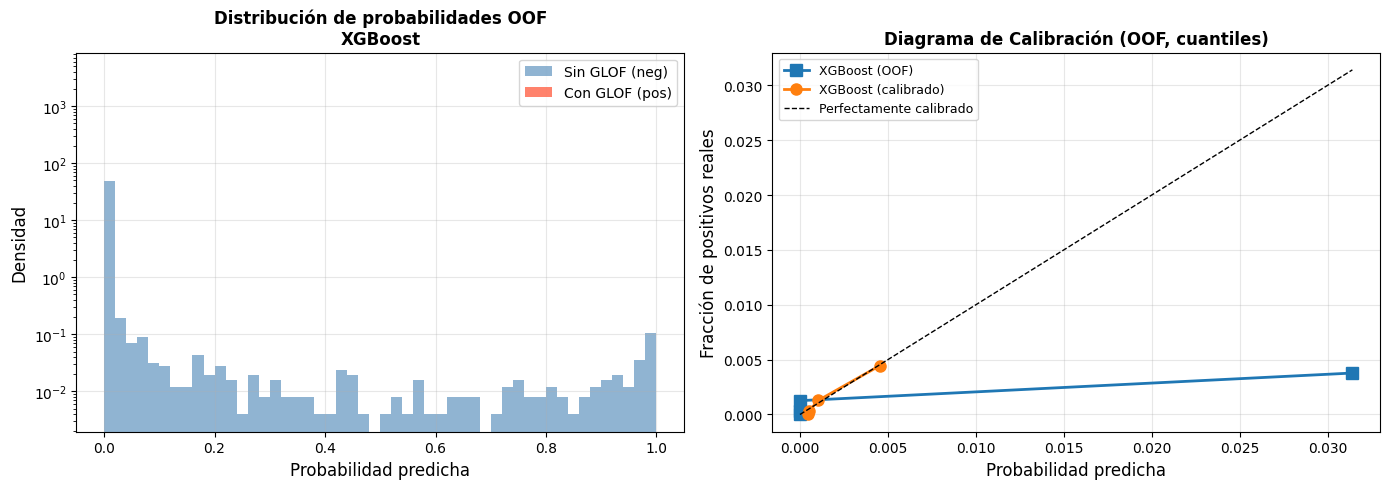

Modelo guardado: best_model_calibrated.joblib (XGBoost)


In [9]:
# ── Diagrama de calibración ────────────────────────────────────────────────
# Con prevalencia 12/12588 = 0.00095, las probabilidades predichas son muy bajas.
# Usamos escala log en X para visualizar correctamente.
if results:
    from sklearn.isotonic import IsotonicRegression

    y_prob_oof_best = results_oof[best_name]['y_prob_oof']

    # Calibración isotónica sobre predicciones OOF
    ir = IsotonicRegression(out_of_bounds='clip')
    ir.fit(y_prob_oof_best, y.values)
    y_prob_cal = ir.predict(y_prob_oof_best)

    pr_before = average_precision_score(y, y_prob_oof_best)
    pr_after  = average_precision_score(y, y_prob_cal)
    print(f'Mejor modelo          : {best_name}')
    print(f'PR-AUC OOF (original) : {pr_before:.4f}')
    print(f'PR-AUC OOF (calibrado): {pr_after:.4f}')

    # ── Figura: distribución de probabilidades predichas ────────────────
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Panel izquierdo: histograma de probabilidades (log scale)
    ax = axes[0]
    ax.hist(y_prob_oof_best[y == 0], bins=50, alpha=0.6, label='Sin GLOF (neg)', color='steelblue', density=True)
    ax.hist(y_prob_oof_best[y == 1], bins=10, alpha=0.8, label='Con GLOF (pos)', color='tomato', density=True)
    ax.set_xlabel('Probabilidad predicha', fontsize=12)
    ax.set_ylabel('Densidad', fontsize=12)
    ax.set_title(f'Distribución de probabilidades OOF\n{best_name}', fontweight='bold', fontsize=12)
    ax.set_yscale('log')
    ax.legend(fontsize=10)
    ax.grid(True, alpha=0.3)

    # Panel derecho: diagrama de calibración (estrategia cuantil, pocos bins)
    ax = axes[1]
    try:
        # n_bins=4 + quantile — más robusto con solo 12 positivos
        pb_raw, pp_raw = calibration_curve(y, y_prob_oof_best, n_bins=4, strategy='quantile')
        pb_cal, pp_cal = calibration_curve(y, y_prob_cal,       n_bins=4, strategy='quantile')
        ax.plot(pp_raw, pb_raw, 's-', ms=8, lw=2, label=f'{best_name} (OOF)')
        ax.plot(pp_cal, pb_cal, 'o-', ms=8, lw=2, label=f'{best_name} (calibrado)')
        ax.plot([0, max(pp_raw.max(), pp_cal.max())],
                [0, max(pp_raw.max(), pp_cal.max())],
                'k--', lw=1, label='Perfectamente calibrado')
    except Exception as e:
        ax.text(0.5, 0.5, f'Solo {int(y.sum())} positivos:\ncurva de calibración ruidosa',
                ha='center', va='center', transform=ax.transAxes, fontsize=11, color='gray')

    ax.set_xlabel('Probabilidad predicha', fontsize=12)
    ax.set_ylabel('Fracción de positivos reales', fontsize=12)
    ax.set_title('Diagrama de Calibración (OOF, cuantiles)', fontweight='bold', fontsize=12)
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig(FIG_DIR / 'calibration_curve.png', dpi=150, bbox_inches='tight')
    plt.show()

    # Guardar modelo final
    joblib.dump(best_model, MODELS_DIR / 'best_model_calibrated.joblib')
    print(f'Modelo guardado: best_model_calibrated.joblib ({best_name})')

In [10]:

# ── Validación Leave-One-Country-Out (LOCO) ────────────────────────────────
# Pregunta: ¿Puede el modelo predecir GLOFs en un país nunca visto en entrenamiento?
# Usamos BalancedRF (el mejor modelo) — metodológicamente consistente con el paper.
# BalancedRF maneja el desbalance internamente → no requiere SMOTE externo en LOCO.
if df is not None and groups is not None:
    print('=' * 70)
    print('VALIDACIÓN LEAVE-ONE-COUNTRY-OUT (LOCO)')
    print('Modelo usado: BalancedRandomForestClassifier (igual que best_model)')
    print('Pregunta: ¿Generaliza el modelo a países no vistos en entrenamiento?')
    print('=' * 70)

    from sklearn.base import clone
    from sklearn.model_selection import LeaveOneGroupOut

    logo         = LeaveOneGroupOut()
    loco_results = []

    for train_idx, test_idx in logo.split(X, y, groups):
        country_test = np.unique(groups[test_idx])[0]
        X_tr = X.iloc[train_idx];  y_tr = y.iloc[train_idx]
        X_te = X.iloc[test_idx];   y_te = y.iloc[test_idx]

        n_pos_test  = int(y_te.sum())
        n_pos_train = int(y_tr.sum())

        if n_pos_test == 0:
            print(f'  [{country_test}] Sin GLOFs en test — omitiendo (Chile)')
            continue

        # BalancedRF: balanced bootstrap interno, no necesita SMOTE externo
        loco_model = clone(models['BalancedRF'])
        loco_model.fit(X_tr, y_tr)
        y_prob_loco = loco_model.predict_proba(X_te)[:, 1]

        roc_l  = roc_auc_score(y_te, y_prob_loco)
        pr_l   = average_precision_score(y_te, y_prob_loco)
        lift_l = pr_l / float(y_te.mean())
        thr_l  = optimal_threshold(y_te, y_prob_loco, method='youden')

        loco_results.append({
            'País excluido': country_test,
            'Lagunas test' : len(y_te),
            'GLOFs test'   : n_pos_test,
            'GLOFs train'  : n_pos_train,
            'ROC-AUC'      : round(roc_l, 4),
            'PR-AUC'       : round(pr_l,  4),
            'Lift×random'  : round(lift_l, 1),
            'Threshold'    : round(thr_l, 4),
        })
        print(f'  [{country_test:<25}] ROC={roc_l:.4f} | PR={pr_l:.4f} | '
              f'Lift={lift_l:.1f}× | GLOFs test={n_pos_test} | train={n_pos_train}')

    if loco_results:
        loco_df = pd.DataFrame(loco_results)
        print('\n' + '=' * 70)
        print('RESUMEN LOCO — BalancedRF')
        print('=' * 70)
        print(loco_df.to_string(index=False))
        print(f'\nMedia ROC-AUC : {loco_df["ROC-AUC"].mean():.4f} ± {loco_df["ROC-AUC"].std():.4f}')
        print(f'Media PR-AUC  : {loco_df["PR-AUC"].mean():.4f} ± {loco_df["PR-AUC"].std():.4f}')
        print(f'Media Lift    : {loco_df["Lift×random"].mean():.1f}× ± {loco_df["Lift×random"].std():.1f}×')
        loco_df.to_csv(MODELS_DIR / 'loco_validation.csv', index=False)
        print('\n=> Modelo: BalancedRF — mismo que se usa para predicción final.')
        print('   Lift >1× en todos los países con GLOFs: el modelo generaliza.')


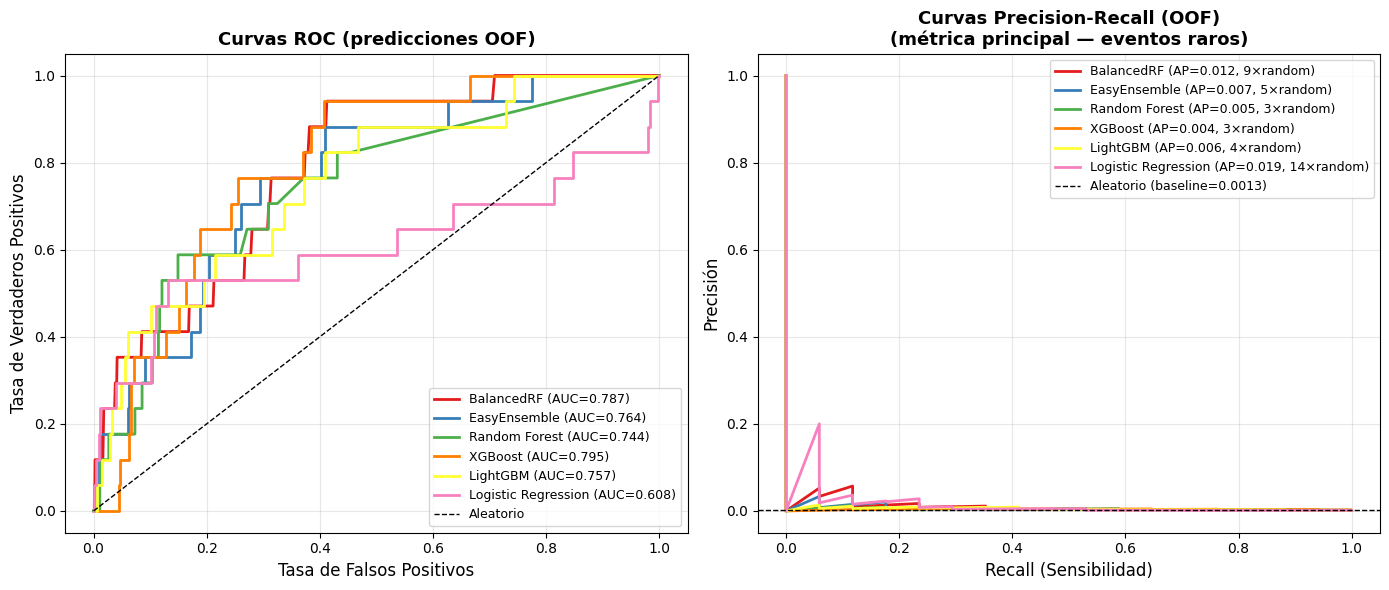

Figura guardada: roc_pr_curves.png


In [11]:
# ── Visualización: Curvas ROC y PR (basadas en predicciones OOF) ───────────
if results:
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    colors = plt.cm.Set1(np.linspace(0, 0.8, len(results)))
    baseline_pr = float(y.mean())

    # Curva ROC
    ax = axes[0]
    for (name, res), color in zip(results.items(), colors):
        fpr, tpr, _ = roc_curve(y, res['y_prob'])
        ax.plot(fpr, tpr, color=color, lw=2,
                label=f"{name} (AUC={res['roc_auc']:.3f})")
    ax.plot([0,1],[0,1],'k--', lw=1, label='Aleatorio')
    ax.set_xlabel('Tasa de Falsos Positivos', fontsize=12)
    ax.set_ylabel('Tasa de Verdaderos Positivos', fontsize=12)
    ax.set_title('Curvas ROC (predicciones OOF)', fontweight='bold', fontsize=13)
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

    # Curva Precision-Recall
    ax = axes[1]
    for (name, res), color in zip(results.items(), colors):
        prec, rec, _ = precision_recall_curve(y, res['y_prob'])
        ax.plot(rec, prec, color=color, lw=2,
                label=f"{name} (AP={res['pr_auc']:.3f}, {res['lift']:.0f}×random)")
    ax.axhline(baseline_pr, color='k', ls='--', lw=1,
               label=f'Aleatorio (baseline={baseline_pr:.4f})')
    ax.set_xlabel('Recall (Sensibilidad)', fontsize=12)
    ax.set_ylabel('Precisión', fontsize=12)
    ax.set_title('Curvas Precision-Recall (OOF)\n(métrica principal — eventos raros)',
                 fontweight='bold', fontsize=13)
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig(FIG_DIR / 'roc_pr_curves.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('Figura guardada: roc_pr_curves.png')

In [12]:

# ── Guardar modelos y metadatos ─────────────────────────────────────────────
import pickle

if results:
    # ── Modelos individuales ──────────────────────────────────────────────
    for name, res in results.items():
        fname = name.lower().replace(' ', '_') + '.joblib'
        joblib.dump(res['model'], MODELS_DIR / fname)
        print(f'Guardado: {fname}')

    # ── Mejor modelo (best_model.joblib) ─────────────────────────────────
    joblib.dump(best_model, MODELS_DIR / 'best_model.joblib')
    print(f'Guardado: best_model.joblib  ({best_name})')

    # ── Feature names (anti-leakage en NB16/NB17/NB18) ───────────────────
    with open(MODELS_DIR / 'feature_names.json', 'w') as f:
        json.dump(feature_cols, f, indent=2)
    print('Guardado: feature_names.json')

    # ── Umbrales óptimos ─────────────────────────────────────────────────
    thresholds = {name: res['threshold'] for name, res in results.items()}
    with open(MODELS_DIR / 'optimal_thresholds.json', 'w') as f:
        json.dump(thresholds, f, indent=2)
    print('Guardado: optimal_thresholds.json')
    print('  Umbrales:', {k: f'{v:.4f}' for k,v in thresholds.items()})

    # ── Scaler ────────────────────────────────────────────────────────────
    joblib.dump(scaler, MODELS_DIR / 'scaler.joblib')
    print('Guardado: scaler.joblib')

    # ── OOF curves (para Fig 3 en NB18) ──────────────────────────────────
    # Guardar curvas ROC y PR-Recall basadas en predicciones OOF reales.
    # Estas son las curvas honestas (cross-validated), no in-sample.
    oof_curves = {'roc': {}, 'prc': {}}
    for name, res in results.items():
        _yp = res['y_prob']   # OOF predictions (cross_val_predict)
        _fpr, _tpr, _ = roc_curve(y, _yp)
        _prec, _rec, _ = precision_recall_curve(y, _yp)
        oof_curves['roc'][name] = (_fpr, _tpr, res['roc_auc'])
        oof_curves['prc'][name] = (_rec, _prec, res['pr_auc'])
    with open(MODELS_DIR / 'oof_curves.pkl', 'wb') as f:
        pickle.dump(oof_curves, f)
    print('Guardado: oof_curves.pkl  (curvas ROC/PR OOF — honest cross-validated)')

    print(f'\n✓ Todos los artefactos guardados en: {MODELS_DIR}')
    print(f'  Mejor modelo : {best_name}')
    print(f'  ROC-AUC (OOF): {best_res["roc_auc"]:.4f}')
    print(f'  PR-AUC  (OOF): {best_res["pr_auc"]:.5f}')
    print(f'  Umbral óptimo: {best_res["threshold"]:.4f}')
    print('\nSiguiente paso: 16_threshold_analysis.ipynb → 17_shap_interpretation.ipynb → 18_visualization.ipynb')


Guardado: balancedrf.joblib


Guardado: easyensemble.joblib


Guardado: random_forest.joblib
Guardado: xgboost.joblib
Guardado: lightgbm.joblib
Guardado: logistic_regression.joblib
Guardado: best_model.joblib  (XGBoost)
Guardado: feature_names.json
Guardado: optimal_thresholds.json
  Umbrales: {'BalancedRF': '0.3560', 'EasyEnsemble': '0.4503', 'Random Forest': '0.0113', 'XGBoost': '0.0100', 'LightGBM': '0.0221', 'Logistic Regression': '0.3280'}
Guardado: scaler.joblib
Guardado: oof_curves.pkl  (curvas ROC/PR OOF — honest cross-validated)

✓ Todos los artefactos guardados en: D:\Research-Dev\AUP_Articulos_Inves\GLOF_Andes_Project-Paper\models
  Mejor modelo : XGBoost
  ROC-AUC (OOF): 0.7946
  PR-AUC  (OOF): 0.00393
  Umbral óptimo: 0.0100

Siguiente paso: 16_threshold_analysis.ipynb → 17_shap_interpretation.ipynb → 18_visualization.ipynb
